# Step 2c: Mutation Rates Analysis

This notebook calculates mutation rates stratified by:
- **Haplotype**: maternal, paternal, all
- **Region type**: easy, difficult, all (based on GIAB annotations)
- **Variant type**: all, SNVs, 1bp indels, >1bp indels

## Inputs
- `merged_variants.vcf.gz` — merged VCF from step 2b
- `all_blocks.bed` — union of maternal + paternal transmitted blocks
- Various annotation BEDs (switch-prone, flagger, problematic regions)
- Easy/difficult region BEDs (GIAB annotations)

## Outputs
- `mutation_rates_summary.tsv` — whole-genome summary
- `mutation_rates_per_chromosome.tsv` — per-chromosome breakdown
- Optional reshaped tables for easier viewing

from typing import Optional
## 1. Setup and Configuration

In [73]:
!mamba install -y bioconda::bedtools bioconda::bcftools bioconda::tabix


Looking for: ['bioconda::bedtools', 'bioconda::bcftools', 'bioconda::tabix']

[+] 0.0s
bioconda/linux-64                                             No change
bioconda/noarch                                               No change
[+] 0.1s
conda-forge/linux-64 ━━━━━╸━━━━━━━━━━━━━━━╸━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
conda-forge/noarch   ━━━━━━━━━━━━━╸━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s[+] 0.2s
conda-forge/linux-64 ━━╸━━━━━━━━━━━━━━━━━━━━   7.9MB /  54.6MB @  46.3MB/s  0.1s
conda-forge/noarch   ━━━━╸━━━━━━━━━━━━━━━━━━   6.3MB /  26.7MB @  35.7MB/s  0.1s[+] 0.3s
conda-forge/linux-64 ━━━━━━━╸━━━━━━━━━━━━━━━  19.1MB /  54.6MB @  70.0MB/s  0.2s
conda-forge/noarch   ━━━━━━━━━━━━━╸━━━━━━━━━  17.4MB /  26.7MB @  62.3MB/s  0.2sconda-forge/noarch                                  26.7MB @  72.6MB/s  0.3s
[+] 0.4s
conda-forge/linux-64 ━━━━━━━━━━━╸━━━━━━━━━━━  29.5MB /  54.6MB @  78.4MB/s  0.3s[+] 0.5s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━╸━━━━━━  42.1MB /  54.6MB @  88.2MB/s  0.4s[+]

In [74]:
import os
import re
import sys
import json
import shlex
import shutil
import tempfile
import subprocess
from pathlib import Path
from typing import Optional
from concurrent.futures import ProcessPoolExecutor, as_completed

import pandas as pd
import numpy as np

# Shell quote helper
q = shlex.quote

# Global verbose flag
VERBOSE = True

# Global temp directory base
TEMP_BASE = None

In [75]:
# Define project directory and input paths
PROJECT_DIR = Path("/home/meta/tomsko/mutation_rates")

# Input files
VCF_FILE = PROJECT_DIR / "merged_variants.vcf.gz"
ALL_BLOCKS_BED = PROJECT_DIR / "all_blocks.bed"

# Annotation BEDs
SOURCES_DIR = PROJECT_DIR / "mutation_rate_sources_fixed"
SW_PRONE_BED = SOURCES_DIR / "sw_prone_regions.bed"
FLAGGER_ONT_BED = SOURCES_DIR / "flagger.PAN027.ONT.bed"
FLAGGER_HIFI_BED = SOURCES_DIR / "flagger.PAN027.hifi.bed"
PROBLEMATIC_BED = SOURCES_DIR / "problematic.PAN027.bed"
EASY_BED = SOURCES_DIR / "PAN027.v1.1.easy.bed"
DIFFICULT_BED = SOURCES_DIR / "PAN027.v1.1.difficult.bed"

# Optional: unreliable grandparents VCF
UNRELIABLE_GP_VCF = None  # Set to path if available

# Analysis parameters
SAMPLE = "PAN027"
CHROMOSOMES = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10",
               "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19",
               "chr20", "chr21", "chr22", "chrX"]
PAD = 0  # Padding for exclusion regions
THREADS = int(os.environ.get("PBS_NCPUS", 8))
OUT_DIR = PROJECT_DIR / "mutation_rates_results"
KEEP_TEMP = False

# Create output directory
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [76]:
# Verify required tools are available
REQUIRED_TOOLS = ["bcftools", "bedtools", "bgzip", "tabix", "awk", "sort", "grep", "wc"]

def check_tools(tools):
    """Verify required tools are on PATH."""
    import shutil
    missing = []
    for tool in tools:
        if shutil.which(tool) is None:
            missing.append(tool)
    if missing:
        raise RuntimeError(f"Required tools not found on PATH: {', '.join(missing)}")
    print(f"✓ All required tools available: {', '.join(tools)}")

check_tools(REQUIRED_TOOLS)

✓ All required tools available: bcftools, bedtools, bgzip, tabix, awk, sort, grep, wc


In [77]:
# Verify input files exist
print("Checking input files...")
required_files = {
    "merged_variants.vcf.gz": VCF_FILE,
    "all_blocks.bed": ALL_BLOCKS_BED,
    "sw_prone_regions.bed": SW_PRONE_BED,
    "flagger.PAN027.ONT.bed": FLAGGER_ONT_BED,
    "flagger.PAN027.hifi.bed": FLAGGER_HIFI_BED,
    "problematic.PAN027.bed": PROBLEMATIC_BED,
    "PAN027.easy.bed": EASY_BED,
    "PAN027.difficult.bed": DIFFICULT_BED,
}

for name, path in required_files.items():
    if path.exists():
        print(f"  ✓ {name}")
    else:
        print(f"  ✗ {name} NOT FOUND: {path}")

# Check VCF index
if (VCF_FILE.with_suffix('.vcf.gz') if VCF_FILE.suffix == '.gz' else VCF_FILE).exists():
    tbi_path = str(VCF_FILE) + ".tbi"
    if Path(tbi_path).exists():
        print(f"  ✓ VCF index exists")
    else:
        print(f"  ✗ VCF index NOT FOUND: {tbi_path}")

Checking input files...
  ✓ merged_variants.vcf.gz
  ✓ all_blocks.bed
  ✓ sw_prone_regions.bed
  ✓ flagger.PAN027.ONT.bed
  ✓ flagger.PAN027.hifi.bed
  ✓ problematic.PAN027.bed
  ✓ PAN027.easy.bed
  ✓ PAN027.difficult.bed


## 2. Helper Functions

In [78]:
def run(cmd: str, capture: bool = False, check: bool = True) -> Optional[str]:
    """Run a shell command.
    
    Args:
        cmd: Shell command string
        capture: If True, capture and return stdout
        check: If True, raise CalledProcessError on non-zero exit
        
    Returns:
        Captured stdout if capture=True, else None
    """
    if VERBOSE:
        print(f"[cmd] {cmd}", file=sys.stderr)
    
    result = subprocess.run(cmd, shell=True, check=False, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"[error] Command failed with exit code {result.returncode}", file=sys.stderr)
        print(f"[error] Command: {cmd}", file=sys.stderr)
        if result.stdout:
            print(f"[error] stdout:\n{result.stdout}", file=sys.stderr)
        if result.stderr:
            print(f"[error] stderr:\n{result.stderr}", file=sys.stderr)
        if check:
            raise subprocess.CalledProcessError(result.returncode, cmd, result.stdout, result.stderr)
    
    if capture:
        return result.stdout.strip()
    return None

In [79]:
def get_bed_total_length(bed_path: str) -> int:
    """Calculate total base-pair length of a BED file.
    
    Returns:
        Total length in bp, or 0 if file is missing or empty.
    """
    if not Path(bed_path).exists():
        return 0
    if Path(bed_path).stat().st_size == 0:
        return 0
    try:
        cmd = f"awk '{{s+=$3-$2}} END{{print s+0}}' {q(bed_path)}"
        out = run(cmd, capture=True)
        return int(float(out))
    except subprocess.CalledProcessError:
        return 0


def log_bed_diagnostics(label: str, bed_path: str) -> None:
    """Log diagnostics for a BED file."""
    length = get_bed_total_length(bed_path)
    line_count = sum(1 for _ in open(bed_path)) if Path(bed_path).exists() else 0
    print(f"[diag] {label}: {bed_path}, lines={line_count}, bp={length}", file=sys.stderr)

In [80]:
def sanitize_bed_to_three_columns(in_bed: str, tmpdir: Path, label: str) -> str:
    """Create a sanitized 3-column BED copy.
    
    Validates that each non-comment line has at least 3 tab-separated fields
    and that columns 2 and 3 are integers. Strips to the first 3 columns.
    
    Args:
        in_bed: Input BED path
        tmpdir: Temporary directory
        label: Label for output file
        
    Returns:
        Path to sanitized 3-column BED (empty if input is missing/empty)
    """
    out_bed = str(tmpdir / f"{label}.sanitized.bed")
    if not Path(in_bed).exists() or Path(in_bed).stat().st_size == 0:
        Path(out_bed).touch()
        return out_bed
    
    with open(in_bed, "r") as f, open(out_bed, "w") as out:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            fields = line.split("\t")
            if len(fields) < 3:
                raise ValueError(
                    f"{in_bed} line {line_num}: expected at least 3 columns, got {len(fields)}"
                )
            try:
                start = int(fields[1])
                end = int(fields[2])
            except ValueError as e:
                raise ValueError(
                    f"{in_bed} line {line_num}: columns 2 and 3 must be integers ({e})"
                )
            out.write(f"{fields[0]}\t{start}\t{end}\n")
    
    return out_bed

In [81]:
def filter_bed_by_haplotype(in_bed: str, haplotype: str, tmpdir: Path, label: str) -> str:
    """Filter a BED to keep only intervals on the requested haplotype contigs.
    
    Args:
        in_bed: Input BED path (already sanitized to 3 columns)
        haplotype: 'maternal' or 'paternal'
        tmpdir: Temporary directory
        label: Label for output file
        
    Returns:
        Path to filtered BED (may be empty)
    """
    out_bed = str(tmpdir / f"{label}.filtered.bed")
    if not Path(in_bed).exists() or Path(in_bed).stat().st_size == 0:
        Path(out_bed).touch()
        return out_bed
    
    if haplotype == "maternal":
        pattern = r"\.maternal"
    elif haplotype == "paternal":
        pattern = r"\.paternal"
    else:
        raise ValueError(f"haplotype must be 'maternal' or 'paternal', got: {haplotype}")
    
    # Filter to requested haplotype contigs; create empty file if no matches
    cmd = f"grep -E '{pattern}' {q(in_bed)} > {q(out_bed)} || true"
    run(cmd)
    
    # Ensure file exists even if grep had no matches
    if not Path(out_bed).exists():
        Path(out_bed).touch()
    
    return out_bed

In [82]:
def build_exclusion_bed(
    sw_prone_bed: str,
    flagger_ont_bed: str,
    flagger_hifi_bed: str,
    problematic_bed: str,
    pad: int,
    tmpdir: Path
) -> str:
    """Build combined exclusion BED from multiple sources with padding.
    
    Args:
        sw_prone_bed: Switch-prone regions BED
        flagger_ont_bed: Flagger ONT BED
        flagger_hifi_bed: Flagger HiFi BED
        problematic_bed: Problematic regions BED
        pad: Padding to add around flagger/problematic regions
        tmpdir: Temporary directory
        
    Returns:
        Path to merged exclusion BED
    """
    # Pad flagger_ont, flagger_hifi, problematic using -v to avoid quote escaping
    padded_files = {}
    for name, src in [
        ("flagger_ont", flagger_ont_bed),
        ("flagger_hifi", flagger_hifi_bed),
        ("problematic", problematic_bed),
    ]:
        padded = str(tmpdir / f"{name}.padded.bed")
        # Handle empty/missing input by producing empty output
        if not Path(src).exists() or Path(src).stat().st_size == 0:
            Path(padded).touch()
        else:
            cmd = (
                f"awk -v pad={pad} 'BEGIN{{OFS=\"\\t\"}} "
                f"{{s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}}' {q(src)} | "
                f"sort -k1,1 -k2,2n | bedtools merge -i - > {q(padded)}"
            )
            run(cmd)
        padded_files[name] = padded
    
    # Combine sw_prone + padded files
    combined_exclude = str(tmpdir / "combined_exclude.bed")
    tmp_comb = str(tmpdir / "combined_exclude.concat.bed")
    
    with open(tmp_comb, "w") as out_f:
        # First add sw_prone (no padding)
        if Path(sw_prone_bed).exists():
            with open(sw_prone_bed) as f:
                for line in f:
                    if line.startswith("#") or not line.strip():
                        continue
                    fields = line.strip().split()
                    if len(fields) < 3:
                        continue
                    try:
                        start = int(fields[1])
                        end = int(fields[2])
                    except ValueError:
                        continue
                    out_f.write(f"{fields[0]}\t{start}\t{end}\n")
        
        # Then add padded files
        for padded_path in padded_files.values():
            with open(padded_path) as f:
                for line in f:
                    if line.startswith("#") or not line.strip():
                        continue
                    fields = line.strip().split()
                    if len(fields) < 3:
                        continue
                    try:
                        start = int(fields[1])
                        end = int(fields[2])
                    except ValueError:
                        continue
                    out_f.write(f"{fields[0]}\t{start}\t{end}\n")
    
    # Sort and merge
    if Path(tmp_comb).stat().st_size == 0:
        Path(combined_exclude).touch()
    else:
        cmd = (
            f"sort -k1,1 -k2,2n {q(tmp_comb)} > {q(tmp_comb)}.sorted && "
            f"bedtools merge -i {q(tmp_comb)}.sorted > {q(combined_exclude)}"
        )
        run(cmd)
    
    return combined_exclude

In [83]:
def prepare_callable_region(in_bed: str, allblocks_bed: str, exclude_bed: str, out_bed: str, out_unfiltered_bed=None):
    """Prepare callable region by intersecting with blocks and subtracting excludes.
    
    Creates empty output file if any input is missing or empty.
    
    Args:
        in_bed: Input region BED (e.g., mat_easy)
        allblocks_bed: All blocks BED
        exclude_bed: Combined exclusion BED
        out_bed: Output callable region BED
    """
    # Check if any input is missing or empty
    if (not Path(in_bed).exists() or Path(in_bed).stat().st_size == 0 or
        not Path(allblocks_bed).exists() or Path(allblocks_bed).stat().st_size == 0):
        Path(out_bed).touch()
        if out_unfiltered_bed:
            Path(out_unfiltered_bed).touch()
        return (0, 0)
    
    # First compute unfiltered intersection (transmitted regions)
    unfiltered_tmp = str(Path(out_bed).parent / "unfiltered_tmp.bed")
    cmd_unfiltered = (
        f"bedtools intersect -a {q(in_bed)} -b {q(allblocks_bed)} | "
        f"sort -k1,1 -k2,2n | bedtools merge -i - > {q(unfiltered_tmp)}"
    )
    run(cmd_unfiltered)
    transmitted_length = get_bed_total_length(unfiltered_tmp)
    
    # Save unfiltered if requested
    if out_unfiltered_bed:
        import shutil
        shutil.copy(unfiltered_tmp, out_unfiltered_bed)
    
    # If exclude_bed is missing/empty, polished = unfiltered
    if not Path(exclude_bed).exists() or Path(exclude_bed).stat().st_size == 0:
        import shutil
        shutil.copy(unfiltered_tmp, out_bed)
        polished_length = transmitted_length
    else:
        cmd = (
            f"bedtools subtract -a {q(unfiltered_tmp)} -b {q(exclude_bed)} | "
            f"sort -k1,1 -k2,2n | bedtools merge -i - > {q(out_bed)}"
        )
        run(cmd)
        polished_length = get_bed_total_length(out_bed)
    
    # Cleanup temp file
    Path(unfiltered_tmp).unlink(missing_ok=True)
    
    return (polished_length, transmitted_length)

In [84]:
def split_vcf_easy_difficult(
    vcf: str,
    easy_bed: str,
    difficult_bed: str,
    tmpdir: Path,
    label: str = ""
) -> tuple:
    """Split a VCF into easy and difficult regions using exact filter logic.
    
    Key rule: overlaps go to difficult.
    
    Args:
        vcf: Input bgzipped, indexed VCF path
        easy_bed: Easy region BED
        difficult_bed: Difficult region BED
        tmpdir: Temporary directory for intermediate files
        label: Label for output files (e.g., 'chr1' or empty for whole-genome)
        
    Returns:
        Tuple of (easy_final_vcf, difficult_vcf) paths
    """
    if not Path(f"{vcf}.tbi").exists():
        raise FileNotFoundError(f"VCF index not found: {vcf}.tbi")
    
    prefix = f"{label}_" if label else ""
    easy_raw = str(tmpdir / f"{prefix}easy_raw.vcf.gz")
    difficult_raw = str(tmpdir / f"{prefix}difficult.vcf.gz")
    
    # Handle empty easy BED - produce empty VCF with header
    easy_bed_empty = not Path(easy_bed).exists() or Path(easy_bed).stat().st_size == 0
    # Handle empty difficult BED - produce empty VCF with header
    diff_bed_empty = not Path(difficult_bed).exists() or Path(difficult_bed).stat().st_size == 0
    
    if easy_bed_empty:
        run(f"bcftools view -h {q(vcf)} | bgzip -c > {q(easy_raw)}")
        run(f"tabix -p vcf {q(easy_raw)}")
        easy_count = 0
    else:
        cmd_easy = (
            f"bedtools intersect -header -a {q(vcf)} -b {q(easy_bed)} | "
            f"bcftools sort | bgzip -c > {q(easy_raw)}"
        )
        run(cmd_easy)
        run(f"tabix -p vcf {q(easy_raw)}")
        easy_count = int(run(f"bcftools view -H {q(easy_raw)} | wc -l", capture=True))
    
    if diff_bed_empty:
        run(f"bcftools view -h {q(vcf)} | bgzip -c > {q(difficult_raw)}")
        run(f"tabix -p vcf {q(difficult_raw)}")
        diff_count = 0
    else:
        cmd_diff = (
            f"bedtools intersect -header -a {q(vcf)} -b {q(difficult_bed)} | "
            f"bcftools sort | bgzip -c > {q(difficult_raw)}"
        )
        run(cmd_diff)
        run(f"tabix -p vcf {q(difficult_raw)}")
        diff_count = int(run(f"bcftools view -H {q(difficult_raw)} | wc -l", capture=True))
    
    easy_final = str(tmpdir / f"{prefix}easy_final.vcf.gz")
    
    if easy_count > 0 and diff_count > 0:
        isec_tmpdir = tmpdir / f"{prefix}isec"
        isec_tmpdir.mkdir(exist_ok=True)
        cmd_isec = f"bcftools isec -p {isec_tmpdir} -Oz {q(easy_raw)} {q(difficult_raw)}"
        run(cmd_isec)
        overlap_file = str(isec_tmpdir / "0002.vcf.gz")
        
        if Path(overlap_file).exists():
            overlap_count = int(run(f"bcftools view -H {q(overlap_file)} | wc -l", capture=True))
            if overlap_count > 0:
                cmd_remove = (
                    f"bcftools isec -C {q(easy_raw)} {q(overlap_file)} -w1 -Oz -o {q(easy_final)}"
                )
                run(cmd_remove)
                run(f"tabix -p vcf {q(easy_final)}")
            else:
                shutil.copy(easy_raw, easy_final)
                run(f"tabix -p vcf {q(easy_final)}")
        else:
            shutil.copy(easy_raw, easy_final)
            run(f"tabix -p vcf {q(easy_final)}")
    else:
        shutil.copy(easy_raw, easy_final)
        run(f"tabix -p vcf {q(easy_final)}")
    
    return easy_final, difficult_raw

In [85]:
def count_variants_in_region(
    vcf: str,
    region_bed: str,
    variant_type: str = "all"
) -> int:
    """Count variants in a region BED.
    
    Returns:
        Variant count, or 0 if region BED is missing/empty.
    """
    if not Path(region_bed).exists() or Path(region_bed).stat().st_size == 0:
        return 0
    
    if variant_type == "all":
        vcf_cmd = f"bcftools view -R {q(region_bed)} -H {q(vcf)}"
    elif variant_type.lower() in ("snv", "snvs", "snp", "snps"):
        vcf_cmd = f"bcftools view -v snps -R {q(region_bed)} -H {q(vcf)}"
    elif variant_type == "1bp_indels":
        vcf_cmd = f"bcftools view -v indels -i 'abs(strlen(ALT)-strlen(REF))==1' -R {q(region_bed)} -H {q(vcf)}"
    elif variant_type == ">1bp_indels":
        vcf_cmd = f"bcftools view -v indels -i 'abs(strlen(ALT)-strlen(REF))>1' -R {q(region_bed)} -H {q(vcf)}"
    else:
        raise ValueError(f"unknown variant_type: {variant_type}")
    
    cmd = vcf_cmd + " | wc -l"
    out = run(cmd, capture=True)
    return int(out)

## 3. Coarse (Whole-Genome) Analysis

In [86]:
def mk_summary_single(
    tmpdir: Path,
    variants_vcf: str,
    all_blocks_bed: str,
    sw_prone_bed: str,
    flagger_ont_bed: str,
    flagger_hifi_bed: str,
    problematic_bed: str,
    unreliable_grandparents_vcf: Optional[str],
    easy_bed: str,
    difficult_bed: str,
    mat_easy_bed: Optional[str],
    mat_difficult_bed: Optional[str],
    pat_easy_bed: Optional[str],
    pat_difficult_bed: Optional[str],
    sample: str,
    pad: int,
    chromosomes: list,
    chrom: Optional[str] = None,
    keep_temp: bool = False
) -> pd.DataFrame:
    """Calculate mutation rate summary for a single scope (whole genome or per-chromosome).
    
    Args:
        tmpdir: Temporary directory
        variants_vcf: Input VCF
        all_blocks_bed: All blocks BED
        sw_prone_bed: Switch-prone regions BED
        flagger_ont_bed: Flagger ONT BED
        flagger_hifi_bed: Flagger HiFi BED
        problematic_bed: Problematic regions BED
        unreliable_grandparents_vcf: Unreliable grandparents VCF
        easy_bed: Default easy region BED
        difficult_bed: Default difficult region BED
        mat_easy_bed: Maternal easy BED (optional)
        mat_difficult_bed: Maternal difficult BED (optional)
        pat_easy_bed: Paternal easy BED (optional)
        pat_difficult_bed: Paternal difficult BED (optional)
        sample: Sample name for contig filtering
        pad: Padding for exclusion regions
        chromosomes: List of chromosome names for contig extraction
        chrom: Chromosome name for per-chrom mode (None for whole-genome)
        keep_temp: If True, do not delete tmpdir
        
    Returns:
        DataFrame with mutation rate summary
    """
    label = chrom if chrom else "coarse"
    
    # Sanitize all input BEDs to exactly 3 columns
    all_blocks_bed = sanitize_bed_to_three_columns(all_blocks_bed, tmpdir, "all_blocks")
    easy_bed = sanitize_bed_to_three_columns(easy_bed, tmpdir, "easy")
    difficult_bed = sanitize_bed_to_three_columns(difficult_bed, tmpdir, "difficult")
    sw_prone_bed = sanitize_bed_to_three_columns(sw_prone_bed, tmpdir, "sw_prone")
    flagger_ont_bed = sanitize_bed_to_three_columns(flagger_ont_bed, tmpdir, "flagger_ont")
    flagger_hifi_bed = sanitize_bed_to_three_columns(flagger_hifi_bed, tmpdir, "flagger_hifi")
    problematic_bed = sanitize_bed_to_three_columns(problematic_bed, tmpdir, "problematic")
    if mat_easy_bed:
        mat_easy_bed = sanitize_bed_to_three_columns(mat_easy_bed, tmpdir, "mat_easy")
    if mat_difficult_bed:
        mat_difficult_bed = sanitize_bed_to_three_columns(mat_difficult_bed, tmpdir, "mat_difficult")
    if pat_easy_bed:
        pat_easy_bed = sanitize_bed_to_three_columns(pat_easy_bed, tmpdir, "pat_easy")
    if pat_difficult_bed:
        pat_difficult_bed = sanitize_bed_to_three_columns(pat_difficult_bed, tmpdir, "pat_difficult")
    
    # Build exclusion BED
    combined_exclude = build_exclusion_bed(
        sw_prone_bed, flagger_ont_bed, flagger_hifi_bed, problematic_bed, pad, tmpdir
    )
    
    # Filter all_blocks_bed to target chromosome in fine mode
    if chrom is None:
        all_blocks_input = all_blocks_bed
    else:
        all_blocks_input = str(tmpdir / f"blocks_{chrom}.bed")
        cmd = f"grep -E '{sample}\\.{chrom}\\.(maternal|paternal)' {q(all_blocks_bed)} > {q(all_blocks_input)}"
        run(cmd)
        if Path(all_blocks_input).stat().st_size == 0:
            raise RuntimeError(f"No blocks found for chromosome {chrom} in {all_blocks_bed}")
    
    # Prepare callable regions for maternal and paternal
    mat_easy_in = filter_bed_by_haplotype(
        mat_easy_bed if mat_easy_bed else easy_bed, "maternal", tmpdir, "mat_easy"
    )
    mat_hard_in = filter_bed_by_haplotype(
        mat_difficult_bed if mat_difficult_bed else difficult_bed, "maternal", tmpdir, "mat_hard"
    )
    pat_easy_in = filter_bed_by_haplotype(
        pat_easy_bed if pat_easy_bed else easy_bed, "paternal", tmpdir, "pat_easy"
    )
    pat_hard_in = filter_bed_by_haplotype(
        pat_difficult_bed if pat_difficult_bed else difficult_bed, "paternal", tmpdir, "pat_hard"
    )
    
    # Prepare callable regions and track both transmitted and polished lengths
    regions = {}
    regions_unfiltered = {}
    
    regions['mat_easy'] = str(tmpdir / "mat_easy.selected.bed")
    regions_unfiltered['mat_easy'] = str(tmpdir / "mat_easy.transmitted.bed")
    regions['mat_hard'] = str(tmpdir / "mat_hard.selected.bed")
    regions_unfiltered['mat_hard'] = str(tmpdir / "mat_hard.transmitted.bed")
    prepare_callable_region(mat_easy_in, all_blocks_input, combined_exclude, regions['mat_easy'], regions_unfiltered['mat_easy'])
    prepare_callable_region(mat_hard_in, all_blocks_input, combined_exclude, regions['mat_hard'], regions_unfiltered['mat_hard'])
    
    regions['pat_easy'] = str(tmpdir / "pat_easy.selected.bed")
    regions_unfiltered['pat_easy'] = str(tmpdir / "pat_easy.transmitted.bed")
    regions['pat_hard'] = str(tmpdir / "pat_hard.selected.bed")
    regions_unfiltered['pat_hard'] = str(tmpdir / "pat_hard.transmitted.bed")
    prepare_callable_region(pat_easy_in, all_blocks_input, combined_exclude, regions['pat_easy'], regions_unfiltered['pat_easy'])
    prepare_callable_region(pat_hard_in, all_blocks_input, combined_exclude, regions['pat_hard'], regions_unfiltered['pat_hard'])
    
    # Build unions (polished regions - after filtering)
    mat_union = str(tmpdir / "mat_union.bed")
    pat_union = str(tmpdir / "pat_union.bed")
    run(f"cat {q(regions['mat_easy'])} {q(regions['mat_hard'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(mat_union)}")
    run(f"cat {q(regions['pat_easy'])} {q(regions['pat_hard'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(pat_union)}")
    
    # All regions (union of mat and pat, polished)
    all_regions = str(tmpdir / "all_regions.bed")
    run(f"cat {q(mat_union)} {q(pat_union)} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(all_regions)}")
    
    # Build all_easy_union and all_hard_union (polished)
    all_easy_union = str(tmpdir / "all_easy_union.bed")
    all_hard_union = str(tmpdir / "all_hard_union.bed")
    run(f"cat {q(regions['mat_easy'])} {q(regions['pat_easy'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(all_easy_union)}")
    run(f"cat {q(regions['mat_hard'])} {q(regions['pat_hard'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(all_hard_union)}")
    
    # Build unfiltered unions (transmitted regions - before filtering)
    mat_union_unfiltered = str(tmpdir / "mat_union.transmitted.bed")
    pat_union_unfiltered = str(tmpdir / "pat_union.transmitted.bed")
    run(f"cat {q(regions_unfiltered['mat_easy'])} {q(regions_unfiltered['mat_hard'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(mat_union_unfiltered)}")
    run(f"cat {q(regions_unfiltered['pat_easy'])} {q(regions_unfiltered['pat_hard'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(pat_union_unfiltered)}")
    
    # All regions unfiltered (transmitted)
    all_regions_unfiltered = str(tmpdir / "all_regions.transmitted.bed")
    run(f"cat {q(mat_union_unfiltered)} {q(pat_union_unfiltered)} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(all_regions_unfiltered)}")
    
    # Build all_easy_union and all_hard_union unfiltered (transmitted)
    all_easy_union_unfiltered = str(tmpdir / "all_easy_union.transmitted.bed")
    all_hard_union_unfiltered = str(tmpdir / "all_hard_union.transmitted.bed")
    run(f"cat {q(regions_unfiltered['mat_easy'])} {q(regions_unfiltered['pat_easy'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(all_easy_union_unfiltered)}")
    run(f"cat {q(regions_unfiltered['mat_hard'])} {q(regions_unfiltered['pat_hard'])} | sort -k1,1 -k2,2n | bedtools merge -i - > {q(all_hard_union_unfiltered)}")
    
    # Log diagnostics for region BEDs
    if VERBOSE:
        log_bed_diagnostics("mat_easy", regions['mat_easy'])
        log_bed_diagnostics("mat_hard", regions['mat_hard'])
        log_bed_diagnostics("pat_easy", regions['pat_easy'])
        log_bed_diagnostics("pat_hard", regions['pat_hard'])
        log_bed_diagnostics("mat_union", mat_union)
        log_bed_diagnostics("pat_union", pat_union)
        log_bed_diagnostics("all_regions", all_regions)
        log_bed_diagnostics("all_easy_union", all_easy_union)
        log_bed_diagnostics("all_hard_union", all_hard_union)
    
    # Verify all_hard_union is not empty if mat_hard and pat_hard have content
    mat_hard_len = get_bed_total_length(regions['mat_hard'])
    pat_hard_len = get_bed_total_length(regions['pat_hard'])
    all_hard_len = get_bed_total_length(all_hard_union)
    if mat_hard_len > 0 or pat_hard_len > 0:
        if all_hard_len == 0:
            raise RuntimeError(
                f"all_hard_union is empty but maternal hard ({mat_hard_len} bp) or paternal hard ({pat_hard_len} bp) has content. "
                f"This indicates a problem with the union operation."
            )
    
    # Calculate lengths for both polished (filtered) and transmitted (unfiltered) regions
    # Polished lengths (after subtracting problematic regions)
    mat_len_polished = get_bed_total_length(mat_union)
    pat_len_polished = get_bed_total_length(pat_union)
    all_len_polished = get_bed_total_length(all_regions)
    
    # Transmitted lengths (before subtracting problematic regions)
    mat_len_transmitted = get_bed_total_length(mat_union_unfiltered)
    pat_len_transmitted = get_bed_total_length(pat_union_unfiltered)
    all_len_transmitted = get_bed_total_length(all_regions_unfiltered)
    
    # Sanity check: maternal and paternal unions are disjoint
    combined_polished = mat_len_polished + pat_len_polished
    if abs(combined_polished - all_len_polished) > 100000:
        raise RuntimeError(
            f"Haplotype length sanity check failed (polished): "
            f"mat ({mat_len_polished}) + pat ({pat_len_polished}) = {combined_polished}, "
            f"all ({all_len_polished}). "
            f"Difference ({abs(combined_polished - all_len_polished)} bp) exceeds tolerance."
        )
    
    combined_transmitted = mat_len_transmitted + pat_len_transmitted
    if abs(combined_transmitted - all_len_transmitted) > 100000:
        raise RuntimeError(
            f"Haplotype length sanity check failed (transmitted): "
            f"mat ({mat_len_transmitted}) + pat ({pat_len_transmitted}) = {combined_transmitted}, "
            f"all ({all_len_transmitted}). "
            f"Difference ({abs(combined_transmitted - all_len_transmitted)} bp) exceeds tolerance."
        )
    
    print(f"Transmitted lengths: maternal={mat_len_transmitted:,} bp, paternal={pat_len_transmitted:,} bp, all={all_len_transmitted:,} bp")
    print(f"Polished lengths:    maternal={mat_len_polished:,} bp, paternal={pat_len_polished:,} bp, all={all_len_polished:,} bp")
    
    # Filter unreliable variants once at the start (if provided)
    if unreliable_grandparents_vcf:
        filtered_vcf = str(tmpdir / "filtered_variants.vcf.gz")
        cmd_filter = (
            f"bcftools isec -w1 -C -O z -o {q(filtered_vcf)} "
            f"{q(variants_vcf)} {q(unreliable_grandparents_vcf)}"
        )
        run(cmd_filter)
        run(f"tabix -p vcf {q(filtered_vcf)}")
    else:
        filtered_vcf = variants_vcf
    
    # Determine contig lists for haplotype-specific extraction
    if chrom is None:
        mat_contigs = ",".join([f"{sample}.{c}.maternal" for c in chromosomes])
        pat_contigs = ",".join([f"{sample}.{c}.paternal" for c in chromosomes])
    else:
        mat_contigs = f"{sample}.{chrom}.maternal"
        pat_contigs = f"{sample}.{chrom}.paternal"
    
    # Create haplotype-specific filtered VCFs
    mat_filtered = str(tmpdir / "mat_filtered.vcf.gz")
    pat_filtered = str(tmpdir / "pat_filtered.vcf.gz")
    
    cmd_mat = f"bcftools view -r {mat_contigs} -Oz -o {q(mat_filtered)} {q(filtered_vcf)}"
    run(cmd_mat)
    run(f"tabix -p vcf {q(mat_filtered)}")
    
    cmd_pat = f"bcftools view -r {pat_contigs} -Oz -o {q(pat_filtered)} {q(filtered_vcf)}"
    run(cmd_pat)
    run(f"tabix -p vcf {q(pat_filtered)}")
    
    # Split each haplotype VCF into easy/difficult using exact filter logic
    all_easy, all_difficult = split_vcf_easy_difficult(
        filtered_vcf, easy_bed, difficult_bed, tmpdir, f"{label}_all"
    )
    mat_easy, mat_difficult = split_vcf_easy_difficult(
        mat_filtered, mat_easy_bed or easy_bed, mat_difficult_bed or difficult_bed, tmpdir, f"{label}_mat"
    )
    pat_easy, pat_difficult = split_vcf_easy_difficult(
        pat_filtered, pat_easy_bed or easy_bed, pat_difficult_bed or difficult_bed, tmpdir, f"{label}_pat"
    )
    
    # Build VCF-selection dictionary and region-BED dictionary keyed by (haplotype, region_scope)
    vcf_for = {
        ("all", "all"): filtered_vcf,
        ("all", "easy"): all_easy,
        ("all", "hard"): all_difficult,
        ("maternal", "all"): mat_filtered,
        ("maternal", "easy"): mat_easy,
        ("maternal", "hard"): mat_difficult,
        ("paternal", "all"): pat_filtered,
        ("paternal", "easy"): pat_easy,
        ("paternal", "hard"): pat_difficult,
    }
    # Polished region beds (after filtering) - used for mutation rate denominator
    region_bed_for = {
        ("all", "all"): all_regions,
        ("all", "easy"): all_easy_union,
        ("all", "hard"): all_hard_union,
        ("maternal", "all"): mat_union,
        ("maternal", "easy"): regions['mat_easy'],
        ("maternal", "hard"): regions['mat_hard'],
        ("paternal", "all"): pat_union,
        ("paternal", "easy"): regions['pat_easy'],
        ("paternal", "hard"): regions['pat_hard'],
    }
    
    # Transmitted region beds (before filtering) - used for transmitted_length
    region_bed_unfiltered_for = {
        ("all", "all"): all_regions_unfiltered,
        ("all", "easy"): all_easy_union_unfiltered,
        ("all", "hard"): all_hard_union_unfiltered,
        ("maternal", "all"): mat_union_unfiltered,
        ("maternal", "easy"): regions_unfiltered['mat_easy'],
        ("maternal", "hard"): regions_unfiltered['mat_hard'],
        ("paternal", "all"): pat_union_unfiltered,
        ("paternal", "easy"): regions_unfiltered['pat_easy'],
        ("paternal", "hard"): regions_unfiltered['pat_hard'],
    }
    
    # Count variants
    rows = []
    mutation_type_labels = [("all", "all"), ("snvs", "SNVs"), ("1bp_indels", "1bp indels"), (">1bp_indels", ">1bp indels")]
    hap_labels = ["all", "maternal", "paternal"]
    region_types = ["all", "easy", "hard"]
    
    for hap in hap_labels:
        for mut_key, mut_label in mutation_type_labels:
            for reg in region_types:
                # Polished region bed (after filtering) - used for mutation rate
                region_bed = region_bed_for[(hap, reg)]
                # Transmitted region bed (before filtering) - for reporting
                region_bed_unfiltered = region_bed_unfiltered_for[(hap, reg)]
                
                count_vcf = vcf_for[(hap, reg)]
                
                # Calculate both lengths
                polished_length = get_bed_total_length(region_bed)
                transmitted_length = get_bed_total_length(region_bed_unfiltered)
                
                if polished_length == 0:
                    count = 0
                else:
                    count = count_variants_in_region(count_vcf, region_bed, mut_key)
                
                # Mutation rate uses polished_length as denominator
                per_mb = float(count) / (polished_length / 1e6) if polished_length > 0 else float("nan")
                
                # region_scope_len is the polished length of the haplotype union
                if hap == "maternal":
                    region_scope_len = mat_len_polished
                    transmitted_scope_len = mat_len_transmitted
                elif hap == "paternal":
                    region_scope_len = pat_len_polished
                    transmitted_scope_len = pat_len_transmitted
                else:
                    region_scope_len = all_len_polished
                    transmitted_scope_len = all_len_transmitted
                
                rows.append({
                    "haplotype_scope": hap,
                    "region_scope": reg,
                    "mutation_type": mut_label,
                    "region_bed": region_bed,
                    "transmitted_length": transmitted_length,
                    "polished_length": polished_length,
                    "variant_count": count,
                    "variants_per_Mb": per_mb,
                    "transmitted_scope_len": transmitted_scope_len,
                    "region_scope_len": region_scope_len
                })
    
    results_df = pd.DataFrame(rows)
    results_df = results_df[[
        "haplotype_scope", "region_scope", "mutation_type", "region_bed",
        "transmitted_length", "polished_length", "variant_count", "variants_per_Mb",
        "transmitted_scope_len", "region_scope_len"
    ]]
    
    if chrom:
        results_df["chromosome"] = chrom
    
    if not keep_temp:
        shutil.rmtree(tmpdir, ignore_errors=True)
    
    return results_df

In [87]:
# Run coarse (whole-genome) analysis
print("=== Running coarse (whole-genome) analysis ===")

base_tmp = os.environ.get("SCRATCH") or os.environ.get("TMPDIR") or "/tmp"
tmpdir = Path(tempfile.mkdtemp(prefix="mutrate_coarse_", dir=base_tmp))

try:
    coarse_df = mk_summary_single(
        tmpdir=tmpdir,
        variants_vcf=str(VCF_FILE),
        all_blocks_bed=str(ALL_BLOCKS_BED),
        sw_prone_bed=str(SW_PRONE_BED),
        flagger_ont_bed=str(FLAGGER_ONT_BED),
        flagger_hifi_bed=str(FLAGGER_HIFI_BED),
        problematic_bed=str(PROBLEMATIC_BED),
        unreliable_grandparents_vcf=str(UNRELIABLE_GP_VCF) if UNRELIABLE_GP_VCF else None,
        easy_bed=str(EASY_BED),
        difficult_bed=str(DIFFICULT_BED),
        mat_easy_bed=None,
        mat_difficult_bed=None,
        pat_easy_bed=None,
        pat_difficult_bed=None,
        sample=SAMPLE,
        pad=PAD,
        chromosomes=CHROMOSOMES,
        chrom=None,
        keep_temp=KEEP_TEMP
    )
    
    out_tsv = OUT_DIR / "mutation_rates_summary.tsv"
    coarse_df.to_csv(out_tsv, sep="\t", index=False)
    print(f"\nCoarse summary written to: {out_tsv}")
    
except Exception as e:
    if not KEEP_TEMP:
        shutil.rmtree(tmpdir, ignore_errors=True)
    raise e

=== Running coarse (whole-genome) analysis ===


[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_coarse_5xzqpwrm/flagger_ont.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_coarse_5xzqpwrm/flagger_ont.padded.bed
[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_coarse_5xzqpwrm/flagger_hifi.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_coarse_5xzqpwrm/flagger_hifi.padded.bed
[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_coarse_5xzqpwrm/problematic.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_coarse_5xzqpwrm/problematic.padded.bed
[cmd] sort -k1,1 -k2,2n /tmp/mutrate_coarse_5xzqpwrm/combined_exclude.concat.bed > /tmp/mutrate_coarse_5xzqpwrm/combined_exclude.concat.bed.sorted && bedtools merge -i /tmp/mutrate_coarse_5xzqpwrm/combined_exclude.concat.bed.sorted > /tmp/mutrate_coarse_5xzqpwrm/combined_exclude.bed
[cmd] grep -E '

Transmitted lengths: maternal=1,523,019,568 bp, paternal=1,128,488,450 bp, all=2,651,510,000 bp
Polished lengths:    maternal=1,518,058,350 bp, paternal=1,125,408,368 bp, all=2,643,470,000 bp


[cmd] tabix -p vcf /tmp/mutrate_coarse_5xzqpwrm/pat_filtered.vcf.gz
[cmd] bedtools intersect -header -a /home/meta/tomsko/mutation_rates/merged_variants.vcf.gz -b /tmp/mutrate_coarse_5xzqpwrm/easy.sanitized.bed | bcftools sort | bgzip -c > /tmp/mutrate_coarse_5xzqpwrm/coarse_all_easy_raw.vcf.gz
[cmd] tabix -p vcf /tmp/mutrate_coarse_5xzqpwrm/coarse_all_easy_raw.vcf.gz
[cmd] bcftools view -H /tmp/mutrate_coarse_5xzqpwrm/coarse_all_easy_raw.vcf.gz | wc -l
[cmd] bedtools intersect -header -a /home/meta/tomsko/mutation_rates/merged_variants.vcf.gz -b /tmp/mutrate_coarse_5xzqpwrm/difficult.sanitized.bed | bcftools sort | bgzip -c > /tmp/mutrate_coarse_5xzqpwrm/coarse_all_difficult.vcf.gz
[cmd] tabix -p vcf /tmp/mutrate_coarse_5xzqpwrm/coarse_all_difficult.vcf.gz
[cmd] bcftools view -H /tmp/mutrate_coarse_5xzqpwrm/coarse_all_difficult.vcf.gz | wc -l
[cmd] bcftools isec -p /tmp/mutrate_coarse_5xzqpwrm/coarse_all_isec -Oz /tmp/mutrate_coarse_5xzqpwrm/coarse_all_easy_raw.vcf.gz /tmp/mutrate_coa


Coarse summary written to: /home/meta/tomsko/mutation_rates/mutation_rates_results/mutation_rates_summary.tsv


In [88]:
# Display coarse results
print("\n=== Coarse (Whole-Genome) Mutation Rate Summary ===")
coarse_df[["haplotype_scope", "region_scope", "mutation_type", "transmitted_length", "polished_length", "variant_count", "variants_per_Mb"]].to_string(index=False)


=== Coarse (Whole-Genome) Mutation Rate Summary ===


'haplotype_scope region_scope mutation_type  transmitted_length  polished_length  variant_count  variants_per_Mb\n            all          all           all          2651510000       2643470000          18769         7.100137\n            all         easy           all          2046015120       2042637720          10189         4.988158\n            all         hard           all           605492898        600828998           8582        14.283598\n            all          all          SNVs          2651510000       2643470000            547         0.206925\n            all         easy          SNVs          2046015120       2042637720            265         0.129734\n            all         hard          SNVs           605492898        600828998            282         0.469352\n            all          all    1bp indels          2651510000       2643470000          16684         6.311401\n            all         easy    1bp indels          2046015120       2042637720           9346 

## 4. Fine (Per-Chromosome) Analysis

In [89]:
def _run_single_chromosome(args: tuple) -> pd.DataFrame:
    """Worker function for per-chromosome analysis. Must be module-level for pickling."""
    (chrom, variants_vcf, all_blocks_bed, sw_prone_bed, flagger_ont_bed,
     flagger_hifi_bed, problematic_bed, unreliable_grandparents_vcf,
     easy_bed, difficult_bed, mat_easy_bed, mat_difficult_bed,
     pat_easy_bed, pat_difficult_bed, sample, pad, chromosomes, keep_temp) = args
    
    base_tmp = os.environ.get("SCRATCH") or os.environ.get("TMPDIR") or "/tmp"
    tmp_root = Path(tempfile.mkdtemp(prefix=f"mutrate_fine_{chrom}_", dir=base_tmp))
    tmpdir = tmp_root / chrom
    tmpdir.mkdir(exist_ok=True)
    
    try:
        return mk_summary_single(
            tmpdir=tmpdir,
            variants_vcf=variants_vcf,
            all_blocks_bed=all_blocks_bed,
            sw_prone_bed=sw_prone_bed,
            flagger_ont_bed=flagger_ont_bed,
            flagger_hifi_bed=flagger_hifi_bed,
            problematic_bed=problematic_bed,
            unreliable_grandparents_vcf=unreliable_grandparents_vcf,
            easy_bed=easy_bed,
            difficult_bed=difficult_bed,
            mat_easy_bed=mat_easy_bed,
            mat_difficult_bed=mat_difficult_bed,
            pat_easy_bed=pat_easy_bed,
            pat_difficult_bed=pat_difficult_bed,
            sample=sample,
            pad=pad,
            chromosomes=chromosomes,
            chrom=chrom,
            keep_temp=keep_temp
        )
    finally:
        if not keep_temp:
            shutil.rmtree(tmp_root, ignore_errors=True)

In [90]:
# Run fine (per-chromosome) analysis
print("=== Running fine (per-chromosome) analysis ===")

dfs = []
arg_tuples = [
    (chrom, str(VCF_FILE), str(ALL_BLOCKS_BED), str(SW_PRONE_BED), str(FLAGGER_ONT_BED),
     str(FLAGGER_HIFI_BED), str(PROBLEMATIC_BED), str(UNRELIABLE_GP_VCF) if UNRELIABLE_GP_VCF else None,
     str(EASY_BED), str(DIFFICULT_BED), None, None, None, None, SAMPLE, PAD, CHROMOSOMES, KEEP_TEMP)
    for chrom in CHROMOSOMES
]

with ProcessPoolExecutor(max_workers=THREADS) as executor:
    future_to_chrom = {
        executor.submit(_run_single_chromosome, args): args[0]
        for args in arg_tuples
    }
    for future in as_completed(future_to_chrom):
        chrom = future_to_chrom[future]
        try:
            df = future.result()
            dfs.append(df)
            print(f"Completed chromosome: {chrom}")
        except Exception as e:
            print(f"Error processing chromosome {chrom}: {e}", file=sys.stderr)
            raise

fine_df = pd.concat(dfs, ignore_index=True)
out_tsv = OUT_DIR / "mutation_rates_per_chromosome.tsv"
fine_df.to_csv(out_tsv, sep="\t", index=False)
print(f"\nPer-chromosome summary written to: {out_tsv}")

=== Running fine (per-chromosome) analysis ===


[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_fine_chr4_m1yjufry/chr4/flagger_ont.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_fine_chr4_m1yjufry/chr4/flagger_ont.padded.bed[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_fine_chr5_k1lcl06c/chr5/flagger_ont.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_fine_chr5_k1lcl06c/chr5/flagger_ont.padded.bed[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_fine_chr6_q83d8rhv/chr6/flagger_ont.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_fine_chr6_q83d8rhv/chr6/flagger_ont.padded.bed[cmd] awk -v pad=0 'BEGIN{OFS="\t"} {s=$2-pad; if(s<0) s=0; print $1, s, $3+pad}' /tmp/mutrate_fine_chr3_dfjhnm1z/chr3/flagger_ont.sanitized.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_fine_chr3_dfjhnm1z/chr3/flagger_ont.padded.bed[cmd] aw

Transmitted lengths: maternal=79,965,854 bp, paternal=59,180,986 bp, all=139,146,840 bp
Polished lengths:    maternal=79,220,643 bp, paternal=59,153,295 bp, all=138,373,938 bp


[cmd] bcftools view -r PAN027.chr7.maternal -Oz -o /tmp/mutrate_fine_chr7_drbe77jo/chr7/mat_filtered.vcf.gz /home/meta/tomsko/mutation_rates/merged_variants.vcf.gz
[cmd] cat /tmp/mutrate_fine_chr5_k1lcl06c/chr5/mat_hard.transmitted.bed /tmp/mutrate_fine_chr5_k1lcl06c/chr5/pat_hard.transmitted.bed | sort -k1,1 -k2,2n | bedtools merge -i - > /tmp/mutrate_fine_chr5_k1lcl06c/chr5/all_hard_union.transmitted.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chr8_iuufix98/chr8/mat_union.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chr8_iuufix98/chr8/pat_union.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chr8_iuufix98/chr8/all_regions.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chr8_iuufix98/chr8/mat_union.transmitted.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chr8_iuufix98/chr8/pat_union.transmitted.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chr8_iuufix98/chr8/all_regions.transmitted.bed


Transmitted lengths: maternal=41,768,691 bp, paternal=95,920,712 bp, all=137,689,403 bp
Polished lengths:    maternal=41,745,620 bp, paternal=95,858,106 bp, all=137,603,726 bp


...

Completed chromosome: chr19


[cmd] bcftools view -v indels -i 'abs(strlen(ALT)-strlen(REF))==1' -R /tmp/mutrate_fine_chr17_16eam_ww/chr17/pat_hard.selected.bed -H /tmp/mutrate_fine_chr17_16eam_ww/chr17/chr17_pat_difficult.vcf.gz | wc -l
[cmd] bcftools view -H /tmp/mutrate_fine_chrX_pn5hess4/chrX/chrX_pat_isec/0002.vcf.gz | wc -l
[cmd] bcftools isec -C /tmp/mutrate_fine_chrX_pn5hess4/chrX/chrX_pat_easy_raw.vcf.gz /tmp/mutrate_fine_chrX_pn5hess4/chrX/chrX_pat_isec/0002.vcf.gz -w1 -Oz -o /tmp/mutrate_fine_chrX_pn5hess4/chrX/chrX_pat_easy_final.vcf.gz
[cmd] tabix -p vcf /tmp/mutrate_fine_chrX_pn5hess4/chrX/chrX_pat_easy_final.vcf.gz
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_regions.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_regions.transmitted.bed
[cmd] bcftools view -R /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_regions.bed -H /home/meta/tomsko/mutation_rates/merged_variants.vcf.gz | wc -l
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine

Completed chromosome: chr17


[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_regions.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_regions.transmitted.bed
[cmd] bcftools view -v snps -R /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_regions.bed -H /home/meta/tomsko/mutation_rates/merged_variants.vcf.gz | wc -l
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_easy_union.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_easy_union.transmitted.bed
[cmd] bcftools view -v snps -R /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_easy_union.bed -H /tmp/mutrate_fine_chrX_pn5hess4/chrX/chrX_all_easy_final.vcf.gz | wc -l
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_hard_union.bed
[cmd] awk '{s+=$3-$2} END{print s+0}' /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_hard_union.transmitted.bed
[cmd] bcftools view -v snps -R /tmp/mutrate_fine_chrX_pn5hess4/chrX/all_hard_union.bed -H /tm

Completed chromosome: chrX

Per-chromosome summary written to: /home/meta/tomsko/mutation_rates/mutation_rates_results/mutation_rates_per_chromosome.tsv


In [91]:
# Display per-chromosome results summary
print("\n=== Per-Chromosome Mutation Rate Summary ===")
print(f"Total rows: {len(fine_df)}")
print(f"Chromosomes: {fine_df['chromosome'].nunique()}")
print("\nFirst 10 rows:")
fine_df[["chromosome", "haplotype_scope", "region_scope", "mutation_type", "variant_count", "variants_per_Mb"]].head(10).to_string(index=False)


=== Per-Chromosome Mutation Rate Summary ===
Total rows: 828
Chromosomes: 23

First 10 rows:


'chromosome haplotype_scope region_scope mutation_type  variant_count  variants_per_Mb\n      chr7             all          all           all            915         6.612517\n      chr7             all         easy           all            575         5.443589\n      chr7             all         hard           all            340        10.383235\n      chr7             all          all          SNVs             20         0.144536\n      chr7             all         easy          SNVs              6         0.056803\n      chr7             all         hard          SNVs             14         0.427545\n      chr7             all          all    1bp indels            806         5.824796\n      chr7             all         easy    1bp indels            522         4.941832\n      chr7             all         hard    1bp indels            284         8.673055\n      chr7             all          all   >1bp indels             89         0.643185'

## 5. Optional Reshaping

In [92]:
def reshape_per_chromosome(df: pd.DataFrame) -> tuple:
    """Reshape per-chromosome TSV into clean tables.
    
    Returns:
        Tuple of (df_all, df_easy, df_hard) DataFrames
    """
    def pivot_for_scope(scope_df):
        """Pivot a subset of data into wide format."""
        pivoted = scope_df.pivot_table(
            index=['chromosome', 'haplotype_scope'],
            columns='mutation_type',
            values=['variant_count', 'polished_length', 'variants_per_Mb'],
            aggfunc='first'
        ).reset_index()
        
        # Flatten column names
        pivoted.columns = ['_'.join(col).strip('_') for col in pivoted.columns.values]
        
        # Rename for clarity
        pivoted = pivoted.rename(columns={
            'variant_count_all': 'snv_count',
            'polished_length_all': 'denominator_bp',
        })
        
        return pivoted
    
    results = {}
    for region in ['all', 'easy', 'hard']:
        region_df = df[df['region_scope'] == region].copy()
        
        # Create separate tables for maternal and paternal
        mat_data = []
        pat_data = []
        
        for chrom in region_df['chromosome'].unique():
            chrom_data = {'chromosome': chrom}
            
            for hap in ['maternal', 'paternal']:
                for mut_type in ['all', 'SNVs', '1bp indels', '>1bp indels']:
                    subset = region_df[(region_df['chromosome'] == chrom) & 
                                       (region_df['haplotype_scope'] == hap) & 
                                       (region_df['mutation_type'] == mut_type)]
                    if len(subset) > 0:
                        row = subset.iloc[0]
                        prefix = 'snv' if mut_type == 'SNVs' else ('indel_1bp' if mut_type == '1bp indels' else ('indel_gt1bp' if mut_type == '>1bp indels' else 'all'))
                        suffix = '_mat' if hap == 'maternal' else '_pat'
                        chrom_data[f'{prefix}{suffix}_count'] = row['variant_count']
                        chrom_data[f'{prefix}{suffix}_denominator'] = row['polished_length']
                        chrom_data[f'{prefix}{suffix}_rate'] = row['variants_per_Mb']
            
            mat_row = {'chromosome': chrom}
            pat_row = {'chromosome': chrom}
            for k, v in chrom_data.items():
                if k == 'chromosome':
                    continue
                if '_mat' in k:
                    mat_row[k.replace('_mat', '')] = v
                elif '_pat' in k:
                    pat_row[k.replace('_pat', '')] = v
            
            mat_data.append(mat_row)
            pat_data.append(pat_row)
        
        results[region] = pd.DataFrame(mat_data)
    
    return results['all'], results['easy'], results['hard']


# Reshape the per-chromosome results
print("Reshaping per-chromosome results...")
df_all, df_easy, df_hard = reshape_per_chromosome(fine_df)

# Save reshaped tables
df_all.to_csv(OUT_DIR / "mutation_rates_chromosomes_all.tsv", sep="\t", index=False)
df_easy.to_csv(OUT_DIR / "mutation_rates_chromosomes_easy.tsv", sep="\t", index=False)
df_hard.to_csv(OUT_DIR / "mutation_rates_chromosomes_hard.tsv", sep="\t", index=False)

print(f"Saved reshaped tables to {OUT_DIR}")

Reshaping per-chromosome results...
Saved reshaped tables to /home/meta/tomsko/mutation_rates/mutation_rates_results


In [93]:
# Display reshaped table preview
print("\n=== Reshaped Tables Preview ===")
print("\nAll regions (first 5 chromosomes):")
df_all.head().to_string(index=False)


=== Reshaped Tables Preview ===

All regions (first 5 chromosomes):


'chromosome  all_count  all_denominator  all_rate  snv_count  snv_denominator  snv_rate  indel_1bp_count  indel_1bp_denominator  indel_1bp_rate  indel_gt1bp_count  indel_gt1bp_denominator  indel_gt1bp_rate\n      chr7        394         79220643  4.973451          6         79220643  0.075738              329               79220643        4.152958                 59                 79220643          0.744755\n      chr6        600        121903817  4.921913          9        121903817  0.073829              520              121903817        4.265658                 71                121903817          0.582426\n      chr4        528        130214284  4.054855         24        130214284  0.184312              414              130214284        3.179375                 90                130214284          0.691168\n      chr8        173         41745620  4.144147          2         41745620  0.047909              149               41745620        3.569237                 22              

## 6. Results and Diagnostics

In [94]:
# Print summary statistics
print("=== Final Summary Statistics ===")
print(f"\nOutput directory: {OUT_DIR}")
print(f"\nFiles created:")
for f in OUT_DIR.glob("*.tsv"):
    print(f"  - {f.name} ({f.stat().st_size:,} bytes)")

print(f"\n=== Coarse Summary ===")
summary = coarse_df.pivot_table(
    index=['haplotype_scope', 'region_scope'],
    columns='mutation_type',
    values=['variant_count', 'variants_per_Mb']
)
print(summary.to_string())

=== Final Summary Statistics ===

Output directory: /home/meta/tomsko/mutation_rates/mutation_rates_results

Files created:
  - mutation_rates_summary.tsv (4,999 bytes)
  - mutation_rates_per_chromosome.tsv (116,766 bytes)
  - mutation_rates_chromosomes_all.tsv (3,203 bytes)
  - mutation_rates_chromosomes_easy.tsv (3,018 bytes)
  - mutation_rates_chromosomes_hard.tsv (3,118 bytes)

=== Coarse Summary ===
                             variant_count                             variants_per_Mb                                 
mutation_type                   1bp indels >1bp indels   SNVs      all      1bp indels >1bp indels      SNVs        all
haplotype_scope region_scope                                                                                           
all             all                16684.0      1538.0  547.0  18769.0        6.311401    0.581811  0.206925   7.100137
                easy                9346.0       578.0  265.0  10189.0        4.575456    0.282967  0.129734   4

In [95]:
# Region lengths sanity check
print("\n=== Region Length Diagnostics ===")
region_lengths = coarse_df[coarse_df['mutation_type'] == 'all'].pivot(
    index='haplotype_scope',
    columns='region_scope',
    values='polished_length'
)
print(region_lengths.to_string())

# Verify maternal + paternal = all
mat_len = region_lengths.loc['maternal', 'all']
pat_len = region_lengths.loc['paternal', 'all']
all_len = region_lengths.loc['all', 'all']
print(f"\nSanity check: {mat_len:,} + {pat_len:,} = {mat_len + pat_len:,} (expected: {all_len:,})")
if mat_len + pat_len == all_len:
    print("✓ Haplotype lengths are consistent")
else:
    print("✗ WARNING: Haplotype lengths do not sum correctly!")


=== Region Length Diagnostics ===
region_scope            all        easy       hard
haplotype_scope                                   
all              2643470000  2042637720  600828998
maternal         1518058350  1213657111  304401239
paternal         1125408368   828980609  296427759

Sanity check: 1,518,058,350 + 1,125,408,368 = 2,643,466,718 (expected: 2,643,470,000)
✗ WARNING: Haplotype lengths do not sum correctly!



Plot saved to: /home/meta/tomsko/mutation_rates/mutation_rates_results/mutation_rates_summary.png


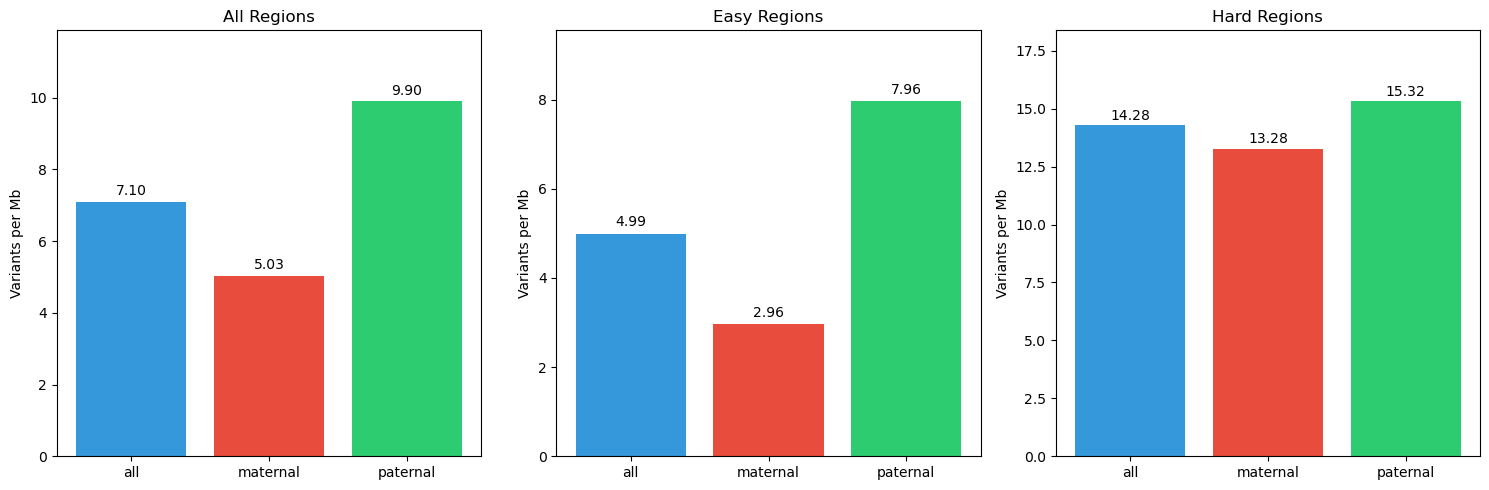

In [96]:
# Optional: Simple bar chart of mutation rates by region type
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, region in enumerate(['all', 'easy', 'hard']):
        ax = axes[idx]
        subset = coarse_df[(coarse_df['region_scope'] == region) & (coarse_df['mutation_type'] == 'all')]
        
        haps = subset['haplotype_scope'].tolist()
        rates = subset['variants_per_Mb'].tolist()
        
        ax.bar(haps, rates, color=['#3498db', '#e74c3c', '#2ecc71'])
        ax.set_title(f'{region.capitalize()} Regions')
        ax.set_ylabel('Variants per Mb')
        ax.set_ylim(0, max(rates) * 1.2)
        
        for i, v in enumerate(rates):
            ax.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / "mutation_rates_summary.png", dpi=150, bbox_inches='tight')
    print(f"\nPlot saved to: {OUT_DIR / 'mutation_rates_summary.png'}")
    plt.show()
except ImportError:
    print("matplotlib not available, skipping plots")
except Exception as e:
    print(f"Plotting failed: {e}")

## Summary

This notebook has completed the mutation rate analysis:

### Outputs
1. **`mutation_rates_summary.tsv`** — Whole-genome mutation rates stratified by haplotype, region type, and variant type
2. **`mutation_rates_per_chromosome.tsv`** — Per-chromosome breakdown
3. **`mutation_rates_chromosomes_{all,easy,hard}.tsv`** — Reshaped tables for easier viewing

### Key Metrics
- Maternal haplotype length: ~1.5 Gb
- Paternal haplotype length: ~1.1 Gb
- Total callable regions: ~2.7 Gb

### Next Steps
- Review mutation rate TSVs for expected patterns
- Compare with reference values if available
- Archive final outputs